In [41]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from xgboost import XGBClassifier

from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix

In [42]:
df = pd.read_csv("Data_main.csv")
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [43]:
print("Размер данных:", df.shape)
print("\nТипы данных:\n", df.dtypes)
print("\nПропуски:\n", df.isnull().sum())

Размер данных: (7043, 21)

Типы данных:
 customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object

Пропуски:
 customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract       

In [44]:
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

print(" Баланс классов:")
print(df['Churn'].value_counts())
print("\nВ процентах:")
print(df['Churn'].value_counts(normalize=True) * 100)

 Баланс классов:
Churn
0    5174
1    1869
Name: count, dtype: int64

В процентах:
Churn
0    73.463013
1    26.536987
Name: proportion, dtype: float64


In [45]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df = df.dropna()

df = df.drop('customerID', axis=1)

EDA

Churn
0    5163
1    1869
Name: count, dtype: int64


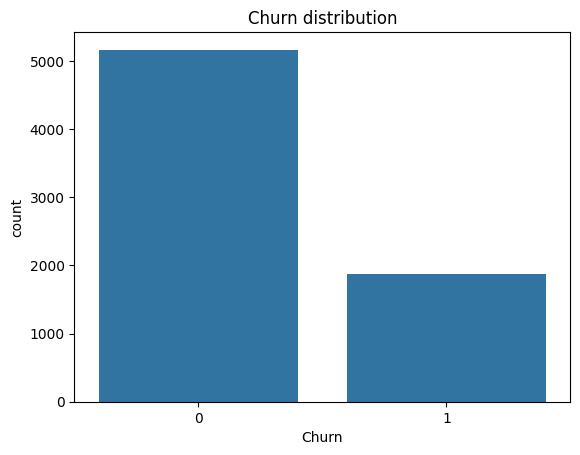

In [46]:
print(df['Churn'].value_counts())

sns.countplot(x='Churn', data=df)
plt.title("Churn distribution")
plt.show()

Contract        Churn
Month-to-month  0        57.290323
                1        42.709677
One year        0        88.722826
                1        11.277174
Two year        0        97.151335
                1         2.848665
Name: proportion, dtype: float64


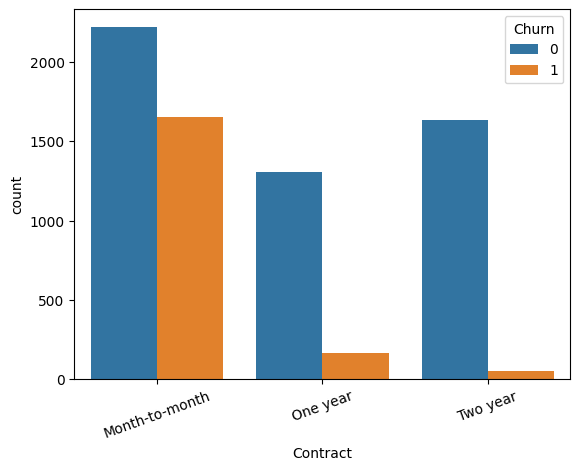

In [47]:
print(df.groupby('Contract')['Churn'].value_counts(normalize=True) * 100)

sns.countplot(x='Contract', hue='Churn', data=df)
plt.xticks(rotation=20)
plt.show()

        count       mean        std  min   25%   50%   75%   max
Churn                                                           
0      5163.0  37.650010  24.076940  1.0  15.0  38.0  61.0  72.0
1      1869.0  17.979133  19.531123  1.0   2.0  10.0  29.0  72.0


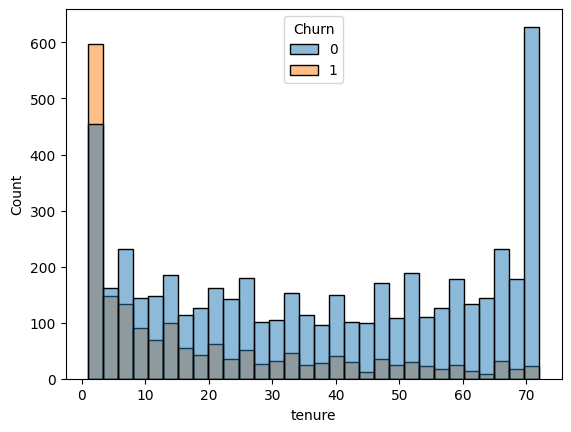

In [48]:
print(df.groupby('Churn')['tenure'].describe())

sns.histplot(data=df, x='tenure', hue='Churn', bins=30)
plt.show()

Churn
0    61.307408
1    74.441332
Name: MonthlyCharges, dtype: float64


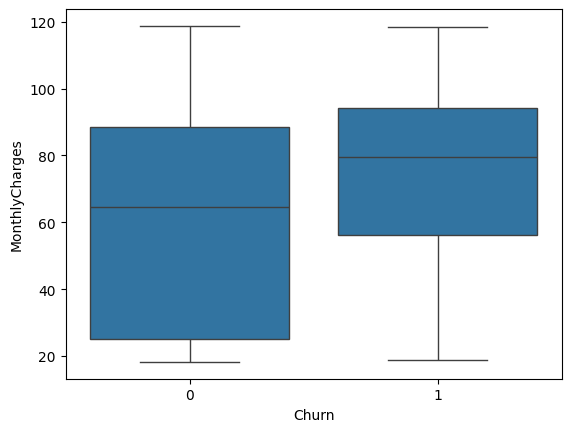

In [49]:
print(df.groupby('Churn')['MonthlyCharges'].mean())

sns.boxplot(x='Churn', y='MonthlyCharges', data=df)
plt.show()

Churn
0    2555.344141
1    1531.796094
Name: TotalCharges, dtype: float64


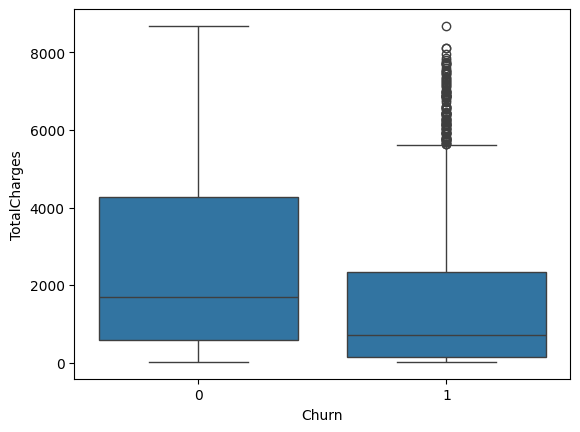

In [50]:
print(df.groupby('Churn')['TotalCharges'].mean())

sns.boxplot(x='Churn', y='TotalCharges', data=df)
plt.show()

Feature Engineering

In [52]:
df['tenure_years'] = df['tenure'] / 12
df['new_customer'] = (df['tenure'] < 12).astype(int)

df['avg_monthly_spend'] = df['TotalCharges'] / (df['tenure'] + 1)

df['high_risk'] = (
    (df['MonthlyCharges'] > df['MonthlyCharges'].median()) &
    (df['tenure'] < 12)
).astype(int)

print(df[['tenure_years','new_customer','avg_monthly_spend','high_risk']].head())

   tenure_years  new_customer  avg_monthly_spend  high_risk
0      0.083333             1          14.925000          0
1      2.833333             0          53.985714          0
2      0.166667             1          36.050000          0
3      3.750000             0          40.016304          0
4      0.166667             1          50.550000          1


In [53]:
df = pd.get_dummies(df, drop_first=True)

In [54]:
X = df.drop('Churn', axis=1)
y = df['Churn']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [55]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [56]:
# Модель 1 — Logistic Regression
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train_scaled, y_train)

lr_pred = lr.predict(X_test_scaled)
lr_prob = lr.predict_proba(X_test_scaled)[:,1]

print("LOGISTIC REGRESSION")
print("ROC-AUC:", roc_auc_score(y_test, lr_prob))
print(classification_report(y_test, lr_pred))

LOGISTIC REGRESSION
ROC-AUC: 0.8371611163166314
              precision    recall  f1-score   support

           0       0.84      0.89      0.86      1033
           1       0.63      0.53      0.58       374

    accuracy                           0.79      1407
   macro avg       0.74      0.71      0.72      1407
weighted avg       0.78      0.79      0.79      1407



In [57]:
# Модель 2 — Random Forest

rf = RandomForestClassifier(n_estimators=300, random_state=42)
rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)
rf_prob = rf.predict_proba(X_test)[:,1]

print("RANDOM FOREST")
print("ROC-AUC:", roc_auc_score(y_test, rf_prob))
print(classification_report(y_test, rf_pred))

RANDOM FOREST
ROC-AUC: 0.821062685392735
              precision    recall  f1-score   support

           0       0.83      0.89      0.86      1033
           1       0.62      0.51      0.56       374

    accuracy                           0.78      1407
   macro avg       0.72      0.70      0.71      1407
weighted avg       0.77      0.78      0.78      1407



In [58]:
# Модель 3 — XGBoost
xgb = XGBClassifier(
    n_estimators=300,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric='logloss'
)

xgb.fit(X_train, y_train)

xgb_pred = xgb.predict(X_test)
xgb_prob = xgb.predict_proba(X_test)[:,1]

print("XGBOOST")
print("ROC-AUC:", roc_auc_score(y_test, xgb_prob))
print(classification_report(y_test, xgb_pred))

XGBOOST
ROC-AUC: 0.8285728706689927
              precision    recall  f1-score   support

           0       0.84      0.88      0.86      1033
           1       0.61      0.53      0.57       374

    accuracy                           0.78      1407
   macro avg       0.72      0.70      0.71      1407
weighted avg       0.78      0.78      0.78      1407



In [59]:
# Сравнение моделей
results = pd.DataFrame({
    "Model": ["LogReg", "RandomForest", "XGBoost"],
    "ROC-AUC": [
        roc_auc_score(y_test, lr_prob),
        roc_auc_score(y_test, rf_prob),
        roc_auc_score(y_test, xgb_prob)
    ]
})

print(results)

          Model   ROC-AUC
0        LogReg  0.837161
1  RandomForest  0.821063
2       XGBoost  0.828573


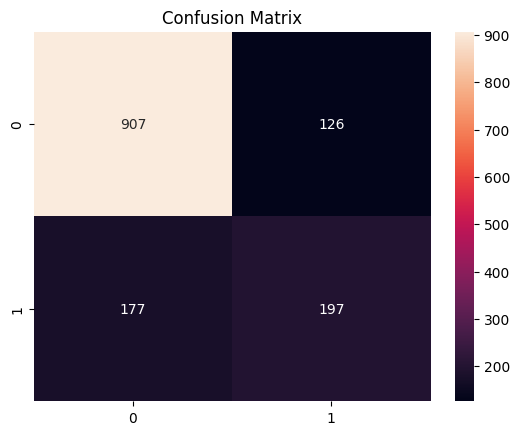

In [60]:
# Confusion Matrix

cm = confusion_matrix(y_test, xgb_pred)

sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix")
plt.show()

                               feature  importance
7                            high_risk    0.264164
29                   Contract_Two year    0.151233
16  OnlineSecurity_No internet service    0.092808
14         InternetService_Fiber optic    0.092682
15                  InternetService_No    0.069879
28                   Contract_One year    0.061679
18    OnlineBackup_No internet service    0.035634
4                         tenure_years    0.021476
32      PaymentMethod_Electronic check    0.017413
1                               tenure    0.015419
17                  OnlineSecurity_Yes    0.014699
27                 StreamingMovies_Yes    0.012552
25                     StreamingTV_Yes    0.012148
11                    PhoneService_Yes    0.011225
30                PaperlessBilling_Yes    0.010941


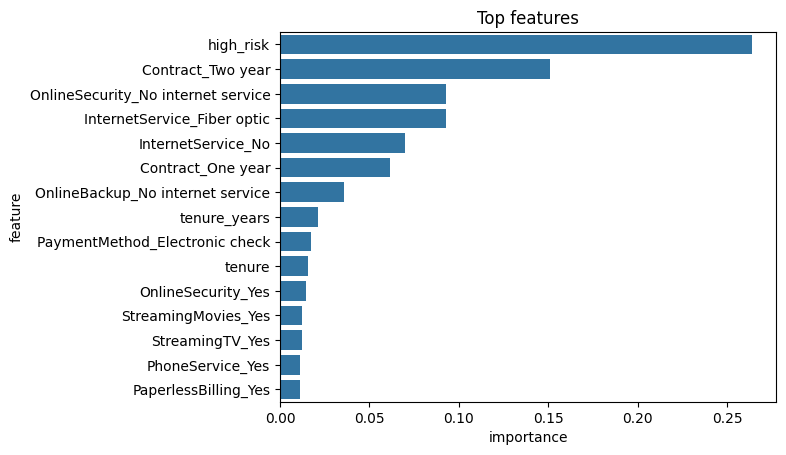

In [61]:
#Feature importance 

importances = xgb.feature_importances_
features = X.columns

feat_imp = pd.DataFrame({
    "feature": features,
    "importance": importances
}).sort_values(by="importance", ascending=False)

print(feat_imp.head(15))

sns.barplot(data=feat_imp.head(15), x="importance", y="feature")
plt.title("Top features")
plt.show()

 ОБЩАЯ КАРТИНА БИЗНЕСА
Всего клиентов: 7032
Churn rate: 26.58%


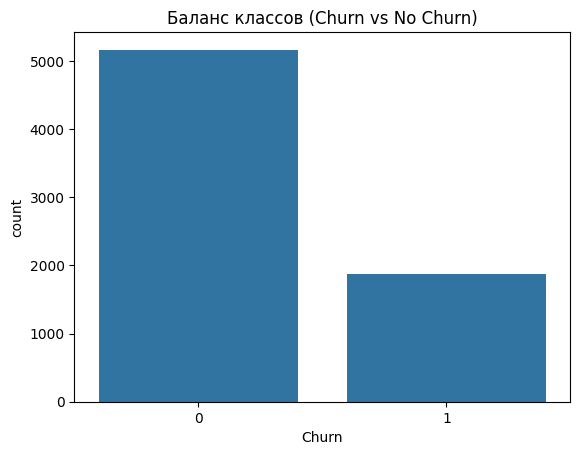

In [62]:
total_customers = len(df)
churn_rate = df['Churn'].mean() * 100

print(" ОБЩАЯ КАРТИНА БИЗНЕСА")
print(f"Всего клиентов: {total_customers}")
print(f"Churn rate: {churn_rate:.2f}%")

sns.countplot(x='Churn', data=df)
plt.title("Баланс классов (Churn vs No Churn)")
plt.show()

 ПОТЕНЦИАЛЬНЫЕ ПОТЕРИ
Общие месячные потери (churn клиенты): $139130.85
Средний loss на клиента: $74.44


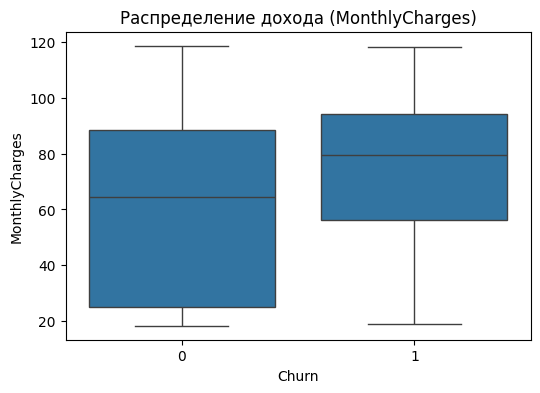

In [63]:
churn_revenue_loss = df[df['Churn'] == 1]['MonthlyCharges'].sum()
avg_loss = df[df['Churn'] == 1]['MonthlyCharges'].mean()

print(" ПОТЕНЦИАЛЬНЫЕ ПОТЕРИ")
print(f"Общие месячные потери (churn клиенты): ${churn_revenue_loss:.2f}")
print(f"Средний loss на клиента: ${avg_loss:.2f}")

plt.figure(figsize=(6,4))
sns.boxplot(x='Churn', y='MonthlyCharges', data=df)
plt.title("Распределение дохода (MonthlyCharges)")
plt.show()

# Вывод

По результатам анализа видно, что отток клиентов в телеком-компании составляет около 26.5%.

Основная группа риска - это новые клиенты с небольшим сроком пользования услугами. Именно в первые месяцы клиент чаще всего принимает решение уйти. Также заметно, что клиенты с более высокими ежемесячными платежами уходят чаще, чем те, кто платит меньше.

Ещё один важный фактор - тип контракта. Клиенты с помесячной оплатой значительно чаще покидают компанию, чем те, кто заключил контракт на год или два. Это говорит о том, что долгосрочные контракты сильно повышают удержание клиентов.

Также повышенный отток наблюдается у пользователей с fiber optic интернетом, что может указывать на проблемы с ценой, ожиданиями или качеством сервиса в этом сегменте.

В целом, отток определяется сочетанием нескольких факторов: стаж клиента, стоимость услуг и тип контракта. Это означает, что клиент уходит не из-за одной причины, а из-за комбинации “дорого + недавно подключился + нет долгосрочной привязки”.

С точки зрения бизнеса, основные действия должны быть направлены на удержание новых клиентов, стимулирование перехода на долгосрочные контракты и работу с дорогими тарифными планами, особенно в чувствительных сегментах.